# TMT4260 Project 1: Diffusion in diffusion couples
Non-isothermal annealing and the Kirkendall effect

Authors: Hedda Kjeldsen, Vegard Stangnes, Isak Vooren

The notebook requires `D_tilda.csv` in the same folder.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
from scipy.interpolate import make_interp_spline
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Part 1: Self-diffusion (tracer diffusion) in a bar

## Part 1 (i): Derivation of the concentration profile from Fick's 2nd law

**The analytical solution (erf), briefly explained**

**The problem.** A bar of pure Cu (or Ni) where half of the atoms are labelled as tracer:
$C = 0$ for $x < 0$, $C = 1$ for $x > 0$. After 30 h at 1000 °C, self-diffusion has smeared out
the sharp boundary in the middle.

**The solution of Fick's 2nd law with these conditions:**

$$C(x,t) = \frac{C_1 + C_2}{2} - \frac{C_1 - C_2}{2}\,\mathrm{erf}\!\left(\frac{x}{2\sqrt{Dt}}\right)$$

- The first term is the mean value, which is where the profile ends up eventually.
- $\mathrm{erf}$ is an S-curve from $-1$ to $+1$ and gives the smooth transition.
- Everything depends on $x/(2\sqrt{Dt})$: **$\sqrt{Dt}$ is the length scale** for how far the
  diffusion has reached. A profile twice as wide takes four times as long.

**The gradient** is the derivative, a Gaussian bell curve with peak
$|C_1 - C_2|/(2\sqrt{\pi D t})$ at $x = 0$. The peak decreases with time, so the driving force for
further diffusion ($J = -D\,\partial C/\partial x$) decreases.

### Finite bar with fixed ends (Fourier series)

Fick's 2nd law on $[-L, L]$ with $L = 1$ mm:

$$\frac{\partial C}{\partial t}=D\frac{\partial^2C}{\partial x^2}$$

**BC:** $C(-L,t)=0$, $C(L,t)=1$ &nbsp;&nbsp; **IC:** $C(x,0)=0$ for $x<0$, $1$ for $x>0$

#### Procedure

1. **Steady state.** $C''=0$ gives $C_{ss}(x)=\tfrac12+\tfrac{x}{2L}$.
2. **Split off** with $u=C-C_{ss}$, so that $u(\pm L,t)=0$. Then $u_0(x)=\tfrac12\operatorname{sgn}(x)-\tfrac{x}{2L}$, which is odd about $x=0$.
3. **Separation of variables** on $u$: $T'=-\lambda DT$ and $X''=-\lambda X$. The boundary conditions give $k=m\pi/L$; the cosine modes vanish because $u_0$ is odd.
4. **Orthogonality** gives $a_m=\tfrac1L\int_{-L}^{L}u_0\sin\tfrac{m\pi x}{L}dx=\tfrac{1}{m\pi}$.

#### Result

$$C(x,t)=\frac{1}{2}+\frac{x}{2L}+\frac{1}{\pi}\sum_{m=1}^{\infty}\frac{1}{m}\sin\!\left(\frac{m\pi x}{L}\right)\exp\!\left(-\frac{m^2\pi^2Dt}{L^2}\right)$$

The first term is the steady state (a straight ramp, not $\tfrac12$ everywhere, since the ends are held fixed), and the second term is the deviation that dies out. Mode $m$ has lifetime $\tau_m = L^2/(m^2\pi^2 D)$.

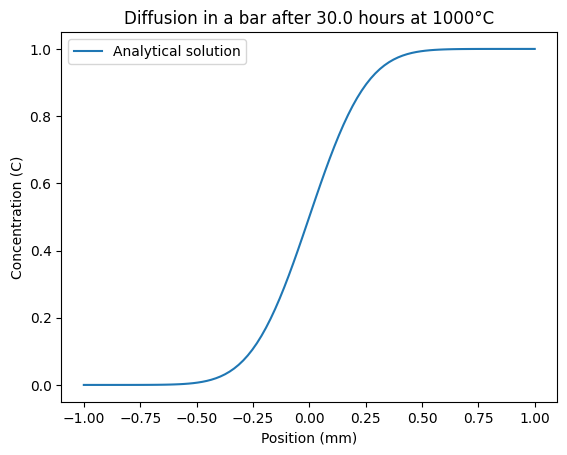

In [2]:
# Analytical solution, finite bar with fixed ends

#------------- Parameters --------
R = 8.3141         # J/(mol*K), gas constant
D0, Q = 31e-6, 200.3e3  # Table 2.2 in P&E, Cu* in Cu (same values as Hedda)
L = 1e-3           # m, distance from the centre to the end of the bar

def D_arrhenius(D0, Q, T):
    # Arrhenius: D = D0 * exp(-Q/RT)
    return D0 * np.exp(-Q / (R * T))


def analytical_solution(x, t, T, M=500):
    # Steady state: straight ramp from C=0 at x=-L to C=1 at x=+L
    D = D_arrhenius(D0, Q, T)  # ~1.9e-13 m^2/s
    C = 0.5 + x / (2 * L)
    # Add the Fourier modes that die out with time
    for m in range(1, M + 1):
        # each mode: amplitude +1/(m*pi), shape factor sin(m*pi*x/L), damping exp(-m^2*pi^2*D*t/L^2)
        C += (1 / (m * np.pi)) * np.sin(m * np.pi * x / L) * np.exp(-(m * np.pi / L) ** 2 * D * t)
    return C

# ------------------- More parameters -------------------
time = 30 * 3600   # s, 30 hours
T = 1000 + 273.15  # K, isothermal annealing at 1000 C
positions = np.linspace(-L, L, 100)  # 100 points from -L to L
# -------------------------------------------------------

analytical_sol = analytical_solution(positions, time, T)
# multiplied by 1e3 to get mm on the x-axis (computed internally in metres since D is in m^2/s)
plt.plot(positions * 1e3, analytical_sol, label='Analytical solution')
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title(f'Diffusion in a bar after {time/3600} hours at 1000°C')
plt.legend()
plt.show()

## Part 1 (ii): Isothermal annealing, analytical solution (30 h at 1000 °C)

Result: plot of concentration vs distance and contration gradient vs distance 
Self diffusion of Ni* and Cu* tracer atoms in bars of Ni and Cu, respectively.

**The diffusion coefficient** $D = D_0 e^{-Q/RT}$, with values from Table 2.2 in P&E:

| Element | $D_0$ (m²/s) | $Q$ (kJ/mol) | $D$ at 1000 °C (m²/s) | $2\sqrt{Dt}$ after 30 h |
|---|---|---|---|---|
| Cu\* in Cu | $31 \cdot 10^{-6}$ | 200.3 | $1.9 \cdot 10^{-13}$ | 0.28 mm |
| Ni\* in Ni | $190 \cdot 10^{-6}$ | 279.7 | $6.4 \cdot 10^{-16}$ | 0.017 mm |

Ni has the highest $D_0$, but the high activation energy dominates: Ni diffuses almost
300 times slower than Cu, and therefore gets a much steeper profile.

**Assumptions:** infinite bar (fine, since $2\sqrt{Dt} \ll L = 1$ mm), constant $D$
(valid for self-diffusion, since the bar is chemically homogeneous; this no longer holds in Part 2, where
Darken's equations are needed), 1D diffusion, and constant $T$ (no longer holds in (iv)).

**Compared with the Fourier solution above:** same physics, but that one is set up for a *finite* bar
with fixed ends. They coincide, since here the profile never reaches the ends, so the boundary conditions
play no role.

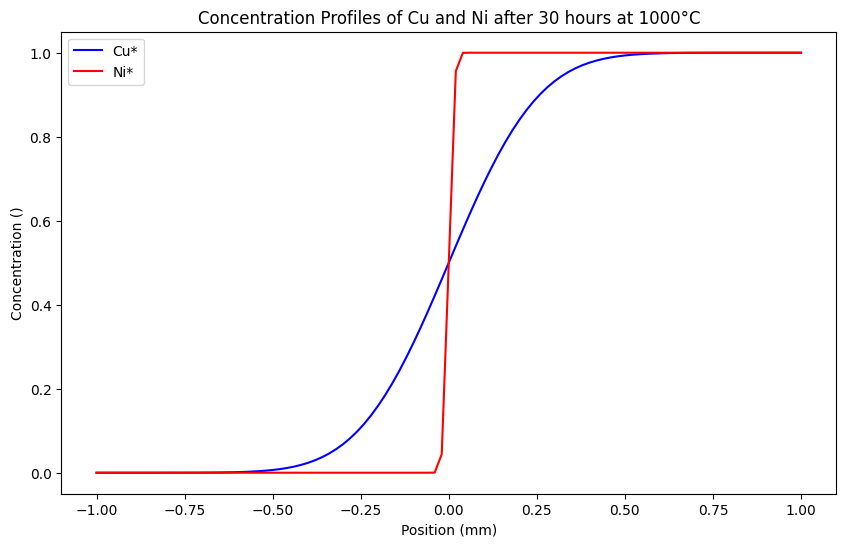

In [3]:
# Problem parameters
T=1000+273.15 # K
t_tot=30*3600 # s
R=8.314 # J/mol*K
x = np.linspace(-1e-3, 1e-3, 101) # m, i.e. from -1 mm to 1 mm

# Material parameters (experimental values from table 2.2 in Porter et al. Phase Transformations in Metals and Alloys)
D0_Cu=31e-6 # m^2/s
D0_Ni=190e-6 # m^2/s
Q_Cu=200.3 # kJ/mol
Q_Ni=279.7 # kJ/mol

# Diffusion coefficient function, D(T)
def Diff_coeff(T, D0, Q):
    return D0*np.exp(-Q*1000/(R*T))

D_Cu=Diff_coeff(T, D0_Cu, Q_Cu)
D_Ni=Diff_coeff(T, D0_Ni, Q_Ni)

# Concentration profile function, C(x,t)
def Concentration_profile(x, t, D, C1, C2):
    return (C1+C2)/2 - (C1-C2)/2 * math.erf(x/(2*np.sqrt(D*t)))

# Calculating concentration profiles for Cu and Ni, with inital condtion: 
# C(x,1)= 1 for x>0 and C(x,1)= 0 for x<0
C_Cu = []  
C_Ni = []

for xi in x:
    C_Cu.append(Concentration_profile(xi, t_tot, D_Cu, 0, 1))
    C_Ni.append(Concentration_profile(xi, t_tot, D_Ni, 0, 1))

# Plotting the concentration profiles
plt.figure(figsize=(10, 6))
plt.plot(x*1e3, C_Cu, label='Cu*', color='blue')
plt.plot(x*1e3, C_Ni, label='Ni*', color='red')
plt.title('Concentration Profiles of Cu and Ni after 30 hours at 1000°C')
plt.xlabel('Position (mm)')     
plt.ylabel('Concentration ()')
plt.legend()
plt.legend()

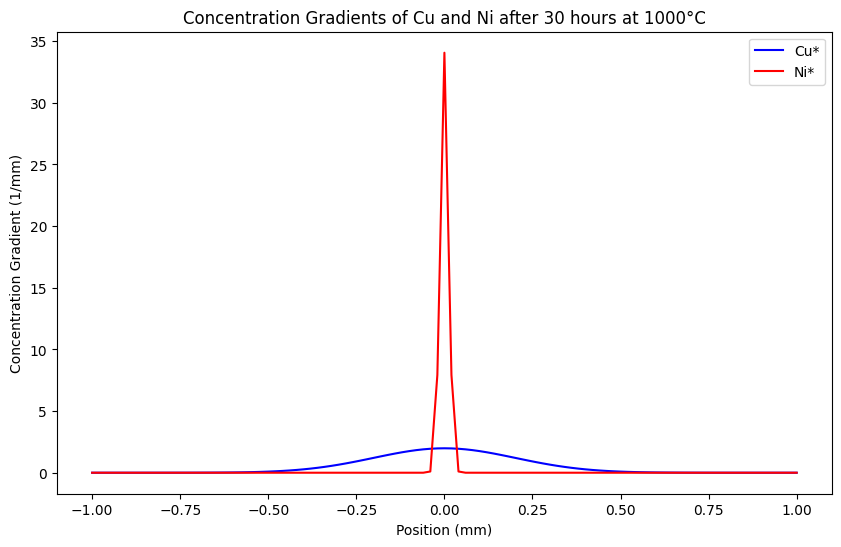

In [4]:
# Concetraion gradients
def Concentration_gradient(x, t, D, C1, C2):
    return -(C1-C2)/(2*np.sqrt(np.pi*D*t)) * np.exp(-x**2/(4*D*t))

Cons_Cu_grad = []
Cons_Ni_grad = []

for xi in x:
    Cons_Cu_grad.append(Concentration_gradient(xi, t_tot, D_Cu, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm
    Cons_Ni_grad.append(Concentration_gradient(xi, t_tot, D_Ni, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm

plt.figure(figsize=(10, 6))
plt.plot(x*1e3, Cons_Cu_grad, label='Cu*', color='blue')
plt.plot(x*1e3, Cons_Ni_grad, label='Ni*', color='red')
plt.title('Concentration Gradients of Cu and Ni after 30 hours at 1000°C')
plt.xlabel('Position (mm)') 
plt.ylabel('Concentration Gradient (1/mm)')
plt.legend()

In [5]:
# sanity checks
print(Concentration_gradient(0, t_tot, D_Cu, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm
print(D_Cu)
print(D_Ni) #NB, diffusion of Ni is very slow. Explaination is that 1000°C is further away from the melting point of Ni than Cu, so diffusion is slower.

1.9819491252865742
1.875777731342469e-13
6.351002637027351e-16


## Part 1 (iii): Numerical solution with the finite difference method

### Explicit FTCS scheme

Numerical solution to substitutional self-diffusion of tracer atoms in bar. I.e. Cu* in Cu and Ni* in Ni (diffusion couple)

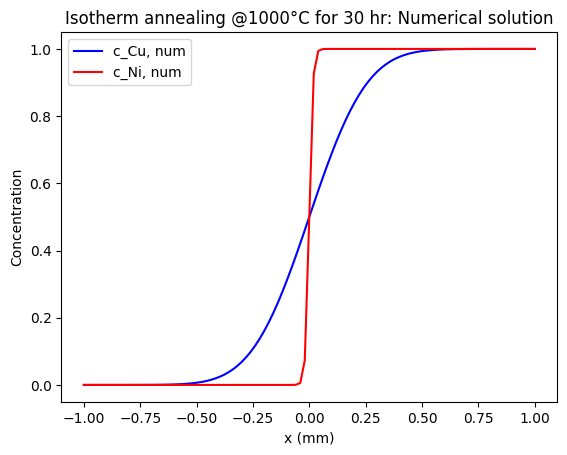

In [6]:
dx_mm = 0.02              # spatial step in mm
dx = dx_mm * 1e-3         # spatial step in m
dt=600 # timestep, seconds (should be within bounds of stability, i.e. dt < dx^2/(2*D))

N = int(t_tot/ dt)   # number of time steps
M = int(2/dx_mm)       # number of spatial steps

# Grid 
x = np.linspace(-1, 1, M+1) # mm
c = np.zeros(M+1)

# Boundary conditions 
# c(x,0) = 1 for x>0, 0 for x<0  
c[x > 0] = 1
c[x < 0] = 0
c[x == 0] = 0.5 # Condition at midpoint

def num_sol(D, c0, dt, dx, N, M):
    """
    D  : diffusion coefficient (m^2/s)
    c0 : initial concentration array (copy of your initial condition)
    dt, dx : time and space steps
    N  : number of time steps
    M  : number of spatial intervals (len(c0) - 1)
    """
    c = c0.copy()   # don't overwrite the caller's original initial condition
    for n in range(N):
        c_new = c.copy()
        for m in range(1, M):
            c_new[m] = D*dt/dx**2 * (c[m+1] - 2*c[m] + c[m-1]) + c[m]
        c_new[0] = c0[0]   # Dirichlet: hold at initial boundary values
        c_new[M] = c0[M]
        c = c_new
    return c

c_Cu = num_sol(D_Cu, c, dt, dx, N, M)
c_Ni = num_sol(D_Ni, c, dt, dx, N, M)

plt.plot(x, c_Cu, label='c_Cu, num', color='blue')  
plt.plot(x, c_Ni, label='c_Ni, num', color='red')
plt.xlabel('x (mm)')
plt.ylabel('Concentration')
plt.title('Isotherm annealing @1000°C for 30 hr: Numerical solution')
plt.legend()
plt.show()

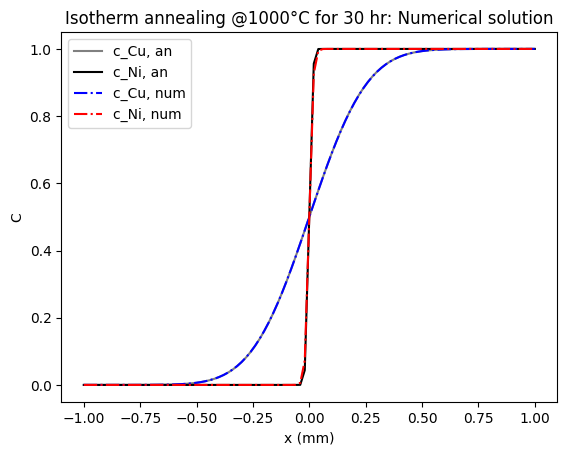

In [7]:
# Plot with analytical solution for comparison 
plt.plot(x, C_Cu, label='c_Cu, an',color='grey')
plt.plot(x, C_Ni, label='c_Ni, an', color='black')
plt.plot(x, c_Cu, label='c_Cu, num',linestyle='dashdot', color='blue')  
plt.plot(x, c_Ni, label='c_Ni, num',linestyle='dashdot', color='red')
plt.xlabel('x (mm)')
plt.ylabel('C')
plt.title('Isotherm annealing @1000°C for 30 hr: Numerical solution')
plt.legend()
plt.show()

### Implicit scheme

In [8]:
#Defining variables to use later
x_min = -1
x_max = 1
x_steps = 120
t_max = 30 # Hours
t_max = t_max * 3600 # Convert to seconds
t_steps = 400

R_kJ = 8.314e-3      # kJ/(mol*K)
T = 1273          # K (1000 °C)

D0_Cu, Q_Cu = 31, 200.3     # mm^2/s, kJ/mol
D0_Ni, Q_Ni = 190, 279.7    # mm^2/s, kJ/mol

D0_Cu = D0_Cu * np.exp(-Q_Cu / (R_kJ * T))   # Cu*  in Cu
D0_Ni = D0_Ni * np.exp(-Q_Ni / (R_kJ * T)) # Ni*  in Ni
D = D0_Cu
# D = 10**-5

In [9]:
def setup(x_min=x_min, x_max=x_max, x_steps=x_steps, t_max=t_max, t_steps=t_steps, D=D):
    x = np.linspace(x_min, x_max, x_steps)
    C_matrix = np.zeros((t_steps, x_steps))
    C_matrix[0, :] = np.heaviside(x, 0.5)   # Using heaviside function to set the first row to 1 for x >= 0 and 0 for x < 0
    dx = (x_max - x_min) / (x_steps - 1)
    dt = t_max / (t_steps - 1)
    r = np.full((x_steps,), D * dt / dx**2)  # r is a vector of length x_steps with the same value D*dt/dx^2
    return C_matrix, dx, dt, r, x

C_matrix, dx, dt, r, x = setup()

In the cell above, a grid of 0s is defined, with the initial condition, C = 1 for positive x and 0 for negative x, is put into the grid. Also, dx, dt and r is defined. The r is defined to make calculations easier, and is a constant for a set time and space step, as well as a constant diffusion coefficiant.

Solving for the next time step for any given space point gives the following:

$$-r\,C_{i-1}^{n+1} + (1+2r)\,C_i^{n+1} - r\,C_{i+1}^{n+1} = C_i^n$$





The cell below solves one step of the implicit system, using a linalg system of this form if Direcht is false, i.e. using Neumann:


$$
\begin{pmatrix}
1+2r & -2r &  &  &  \\
-r & 1+2r & -r &  & \Large{0} \\
 & \ddots & \ddots & \ddots &  \\
\Large{0} &  & -r & 1+2r & -r \\
 &  &  & -2r & 1+2r
\end{pmatrix}
\begin{pmatrix}
C_0^{n+1} \\ C_1^{n+1} \\ \vdots \\ C_{N-1}^{n+1} \\ C_N^{n+1}
\end{pmatrix}
=
\begin{pmatrix}
C_0^{n} \\ C_1^{n} \\ \vdots \\ C_{N-1}^{n} \\ C_N^{n}
\end{pmatrix}
$$

Here, the 2r points are because of the mirroring of these end points. 

And similarly for Direcht true, this is implemented to hold the end points constant:
$$
\begin{pmatrix}
1 & 0 &  &  &  \\
-r & 1+2r & -r &  & \Large{0} \\
 & \ddots & \ddots & \ddots &  \\
\Large{0} &  & -r & 1+2r & -r \\
 &  &  & 0 & 1
\end{pmatrix}
\begin{pmatrix}
C_0^{n+1} \\ C_1^{n+1} \\ \vdots \\ C_{N-1}^{n+1} \\ C_N^{n+1}
\end{pmatrix}
=
\begin{pmatrix}
C_0^{n} \\ C_1^{n} \\ \vdots \\ C_{N-1}^{n} \\ C_N^{n}
\end{pmatrix}
$$

The first and last rows are replaced by identity rows, which enforce $C_0^{n+1} = C_0^{n}$ and $C_N^{n+1} = C_N^{n}$. The boundary values are therefore carried unchanged from the initial condition, here 0 and 1.

Eliminating the boundary nodes under the Dirichlet condition leaves a
symmetric, positive definite tridiagonal system for the interior unknowns,
which permits a Cholesky factorization instead of LU.

In [10]:
def implicit_system_one_step(C_matrix, r, step, s=None, Dirichlet=False):
    C0 = C_matrix[step, :]                      # Takes the step-th row of the C_matrix and stores it in C0
    # print(C0)
    if s is None:
        s = np.zeros_like(C0)
    A = np.zeros((len(C0), len(C0)))            # Creates a square matrix of zeros with the same length as C0 to be filled in. This as most of the matrix is 0s anyway.

    for i in range(0, len(C0)):                 # See structure in the markdown cell above. We only fill in the diagonal and the two diagonals next to it. 
        A[i, i] = 2*r[i] + 1
        if i != 0:
            A[i, i-1] = -r[i] + s[i]
        if i != len(C0)-1:
            A[i, i+1] = -r[i] - s[i]
    if not Dirichlet:
        A[0, 1] = -2*r[0]                       # Adding the end points to fulfill the boundry conditions.
        A[-1, -2] = -2*r[-1]
    elif Dirichlet:
        A[0, 0] = 1
        A[0, 1] = 0
        A[-1, -1] = 1
        A[-1, -2] = 0
    np.set_printoptions(precision=3, suppress=True, linewidth=120)
    # print(A)
    C1 = np.linalg.solve(A, C0)                 # Could be replaced by scipy for increase speed.
    # print(C1)
    return C1

In [11]:
def main():
    for step in range(0, t_steps-1):
        C_matrix[step+1, :] = implicit_system_one_step(C_matrix, r, step)
    return C_matrix

C_matrix = main()

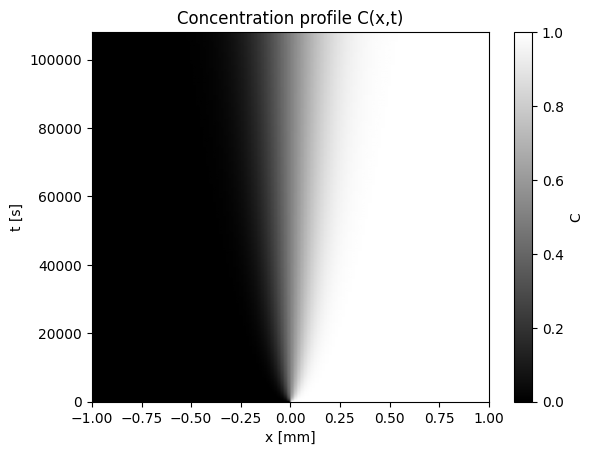

In [12]:
plt.imshow(C_matrix, aspect='auto', origin='lower', cmap='gray',
           extent=[x_min, x_max, 0, t_max])
plt.colorbar(label='C')
plt.xlabel('x [mm]')
plt.ylabel('t [s]')
plt.title('Concentration profile C(x,t)')
plt.show()

In [13]:
def plot_profiles(C_matrix, x_min, x_max, dt, n_curves=2, title = ""):
    plt.close('all')          # closes old figures

    t_steps, x_steps = C_matrix.shape
    x = np.linspace(x_min, x_max, x_steps)

    steps = np.linspace(0, t_steps - 1, n_curves, dtype=int)
    colors = plt.cm.viridis(np.linspace(0, 0.9, n_curves))

    plt.figure(figsize=(7, 4.5))
    for c, n in zip(colors, steps):
        plt.plot(x, C_matrix[n], color=c, lw=1.8, label=f'{n*dt/3600:.1f} h')
    plt.xlabel('$x$ [mm]')
    plt.ylabel('$C$')
    plt.xlim(x_min, x_max)
    plt.ylim(-0.02, 1.02)
    plt.grid(alpha=0.3, lw=0.5)
    plt.legend(frameon=False, title='$t$')
    plt.title(title)
    plt.tight_layout()
    plt.show()

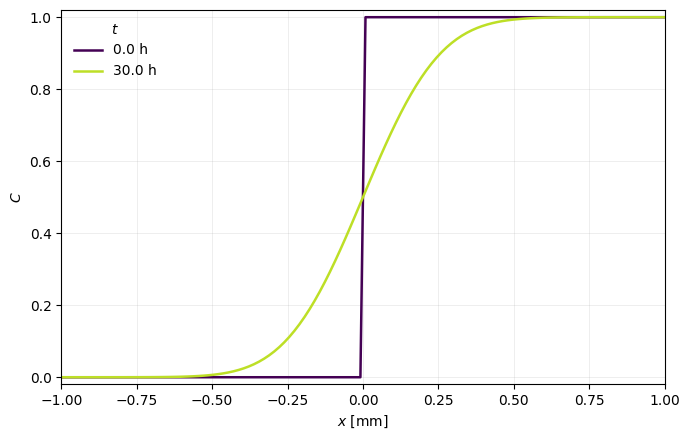

In [14]:
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main()

plot_profiles(C_matrix, x_min, x_max, dt, n_curves=2)

### Explicit scheme in flux form: fixed ends and zero-flux ends

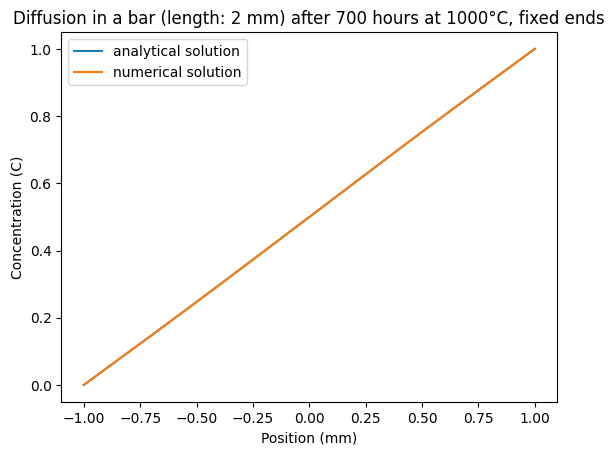

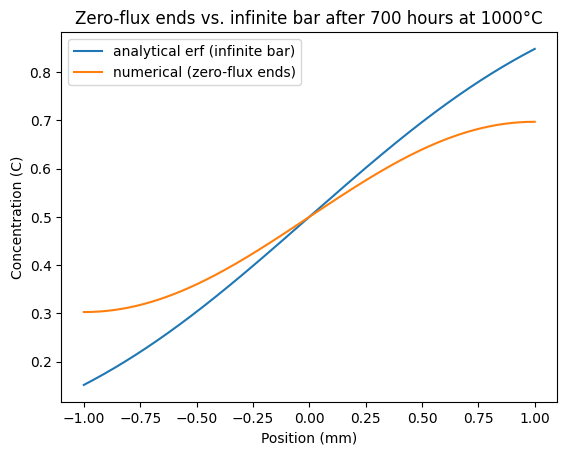

In [15]:
# Solution with the finite difference method, constant diffusion coefficient D and temperature T

def central_diff(C, D, dx, D_list = None):
    if D_list is not None:
        # D midway between the nodes:  D_{j+1/2} = (D_j + D_{j+1}) / 2
        D_face = 0.5 * (D_list[:-1] + D_list[1:])
        # Fick's 1st law on the faces:  J_{j+1/2} = -D_{j+1/2} * (C_{j+1} - C_j) / dx
        J = -D_face * (C[1:] - C[:-1]) / dx        # C[1:] = C_{j+1},  C[:-1] = C_j
    else:
        J = -D * (C[1:] - C[:-1]) / dx

    # dC_j/dt = -(J_{j+1/2} - J_{j-1/2}) / dx
    dCdt = np.zeros_like(C)
    dCdt[1:-1] = -(J[1:] - J[:-1]) / dx           # J[1:] = J_{j+1/2},  J[:-1] = J_{j-1/2}
    return dCdt, J

def iteration_1(C, D, dx, t_end, alpha=0.4):
    # dt is computed from stability: alpha = D*dt/dx^2 <= 0.5
    dt = alpha * dx**2 / D
    t = 0
    C = np.array(C, dtype=float)
    history = [C.copy()]
    while t < t_end:
        dcdt, J = central_diff(C, D, dx)
        C = C + dt * dcdt
        history.append(C.copy())
        t += dt
    return history

def iteration_2(C, D, dx, t_end, alpha=0.4):
    # dt is computed from stability: alpha = D*dt/dx^2 <= 0.5
    dt = alpha * dx**2 / D
    t = 0
    C = np.array(C, dtype=float)
    history = [C.copy()]
    while t < t_end:
        dcdt, J = central_diff(C, D, dx)
        C = C + dt * dcdt
        C[0]=C[1]; C[-1]=C[-2] # Different boundary condition, not fixed ends
        history.append(C.copy())
        t += dt
    return history

#----------- Parameters -----------------
grid_points = 300 # number of points
t_end = 3600 * 700 # s, 700 hours
T = 1000 + 273 # K
L = 1e-3 # m, distance from the centre to the ends of the bar


D0, Q = 31e-6, 200.3e3  # Table 2.2 in P&E, Cu* in Cu (same values as Hedda)

# C_grid
concentrations = np.zeros(grid_points)
concentrations[grid_points//2:] = 1.0

# positions
dx = 2*L / (grid_points - 1)   # same spacing as linspace gives
positions = np.linspace(-L,L,grid_points)
positions_fine = np.linspace(-L,L,1000)
D = D_arrhenius(D0, Q, T)

# ------------- Fixed concentration at the ends (C=0 at x=-L, C=1 at x=L) ----------------
analy = analytical_solution(positions_fine, t_end, T)
num = iteration_1(concentrations,D,dx,t_end,alpha=0.4)
plt.plot(positions_fine * 1e3,analy,label="analytical solution")
plt.plot(positions * 1e3,num[-1],label="numerical solution")   # num[-1] = last time step
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title(f'Diffusion in a bar (length: {2*L*1e3:.0f} mm) after {t_end/3600:.0f} hours at {T-273}°C, fixed ends')
plt.legend()
plt.show()

# -------------- Fixed amount in the whole bar -------------------------------
# Concentration_profile is Hedda's function from Part 1 (ii).
# C1=0, C2=1 gives the same orientation as here: C=0 for x<0, C=1 for x>0
analy_erf = [Concentration_profile(xi, t_end, D, 0, 1) for xi in positions_fine]
num_2 = iteration_2(concentrations, D, dx, t_end, alpha=0.4)   # zero flux: C[0]=C[1], C[-1]=C[-2]

plt.figure()
plt.plot(positions_fine * 1e3, analy_erf, label="analytical erf (infinite bar)")
plt.plot(positions * 1e3, num_2[-1], label="numerical (zero-flux ends)")
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title(f'Zero-flux ends vs. infinite bar after {t_end/3600:.0f} hours at {T-273}°C')
plt.legend()
plt.show()

## Part 1 (iv): Non-isothermal annealing (10 °C/h from 700 to 1000 °C)

#### Why $D$ is computed inside the loop

In isothermal annealing $T$ is constant, so $D$ can be computed once before the loop. Here
$T$ rises steadily from 700 to 1000 °C, and since $D = D_0 e^{-Q/RT}$, $D$ changes all the way.
It must therefore be updated every time step, using the temperature at that moment:

```python
D = D_arrhenius(D0, Q, T_start + t * DT_dt)
```

The time step has to be moved inside the loop for the same reason: the stability criterion
$dt = \alpha\,dx^2/D$ depends on $D$. When the bar is cold, long time steps are allowed, and
as it heats up the steps must get shorter for the solution to remain stable.

Number of iterations: 637
Number of iterations: 640


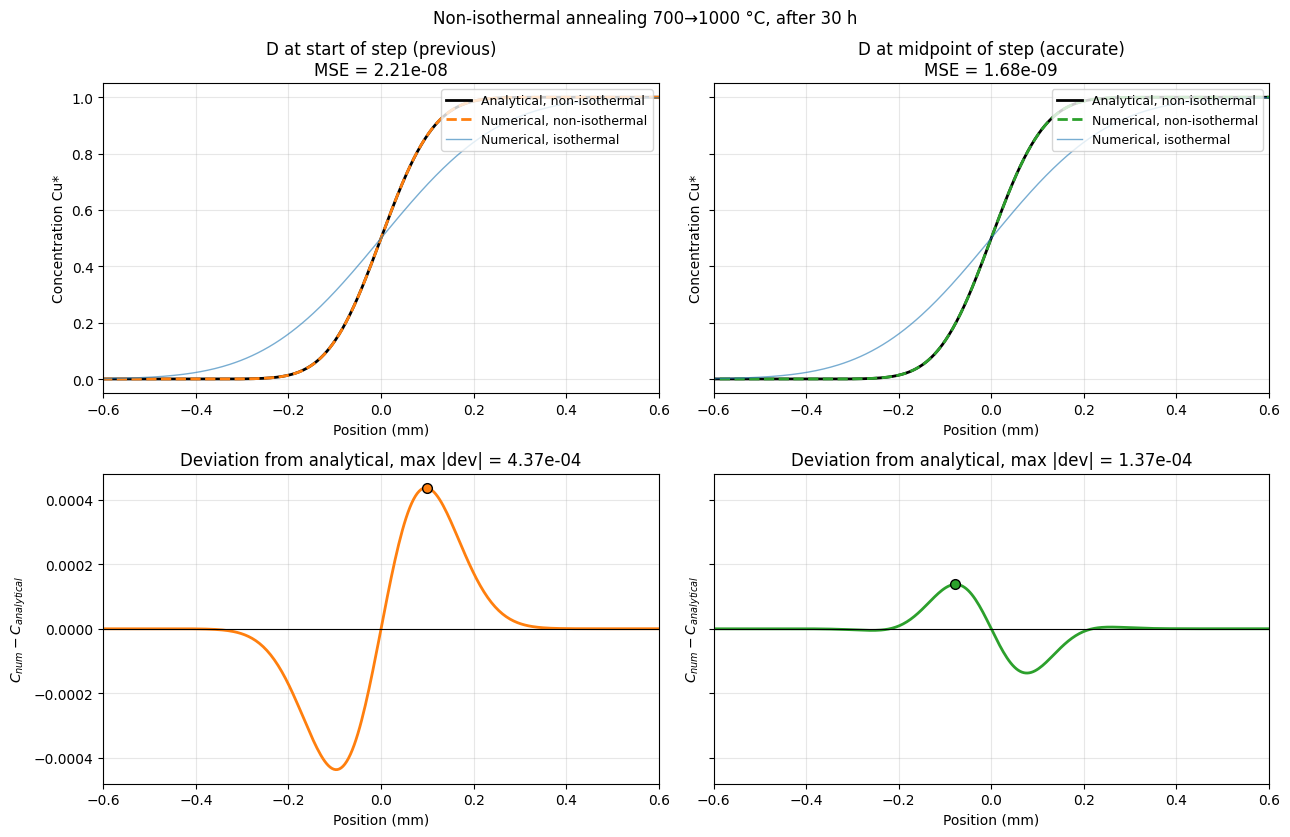

In [16]:
# Non-isothermal annealing

def iteration_annealing(C,T_start,T_end,dx,t_end,alpha=0.4):
    t = 0
    DT_dt = (T_end - T_start) / t_end
    C = np.array(C, dtype=float)
    history = [C.copy()]
    iterations = 0
    while t < t_end:
        D = D_arrhenius(D0, Q, T_start + (t * DT_dt))
        dt = alpha * dx**2 / D
        dcdt, J = central_diff(C, D, dx)
        C = C + dt * dcdt
        history.append(C.copy())
        t += dt
        iterations += 1
    print("Number of iterations:", iterations)
    return history

def iteration_annealing_accurate(C,T_start,T_end,dx,t_end,alpha=0.4):
    t = 0
    DT_dt = (T_end - T_start) / t_end
    C = np.array(C, dtype=float)
    history = [C.copy()]
    iterations = 0
    D = D_arrhenius(D0, Q, T_start)
    while t < t_end:
        dt = alpha * dx**2 / D
        D = D_arrhenius(D0, Q, T_start + (t + dt/2) * DT_dt)
        dt = alpha * dx**2 / D
        dcdt, J = central_diff(C, D, dx)
        C = C + dt * dcdt
        history.append(C.copy())
        t += dt
        iterations += 1
    print("Number of iterations:", iterations)
    return history

def accumulated_Dt(T_start, T_final, t_end, n=10000):
    t = np.linspace(0, t_end, n)
    T_of_t = T_start + (T_final - T_start) * t / t_end
    return np.trapezoid(D_arrhenius(D0, Q, T_of_t), t)

def analytical_annealing(x, Dt, M=500):
    C = 0.5 + x / (2 * L)
    for m in range(1, M + 1):
        C += (1/(m*np.pi)) * np.sin(m*np.pi*x/L) * np.exp(-(m*np.pi/L)**2 * Dt)
    return C

#------------ Parameters -----------------
grid_points = 500 # number of points
t_end = 3600 * 30 # s, 30 hours
T = 1000 + 273 # K
L = 1e-3 # m, distance from the centre to the ends of the bar
T_start = 700 + 273 # K
T_final = 1000 + 273 # K


D0, Q = 31e-6, 200.3e3  # Table 2.2 in P&E, Cu* in Cu (same values as Hedda)

# C_grid
concentrations = np.zeros(grid_points)
concentrations[grid_points//2:] = 1.0

# positions
dx = 2*L / (grid_points - 1)   # same spacing as linspace gives
positions = np.linspace(-L,L,grid_points)
positions_fine = np.linspace(-L,L,1000)


Dt = accumulated_Dt(T_start, T_final, t_end)   # replaces D*t when D is not constant
analy = analytical_annealing(positions_fine, Dt)
num = iteration_annealing(concentrations,T_start,T_final,dx,t_end)
num_accurate = iteration_annealing_accurate(concentrations,T_start,T_final,dx,t_end)
num_isothermal = iteration_1(concentrations,D,dx,t_end)

# ---------- Comparison at 30 h: D at start of step vs D at midpoint ----------
analy_grid = analytical_annealing(positions, Dt)   # analytical solution on the same grid as the numerical

def mse(C_num):
    # mean squared error against the analytical solution
    return np.mean((C_num - analy_grid)**2)

def max_dev(C_num):
    # largest absolute deviation from the analytical solution, and where it occurs
    dev = C_num - analy_grid
    i = np.argmax(np.abs(dev))
    return dev[i], positions[i]

fig, axs = plt.subplots(2, 2, figsize=(13, 8.5), sharey='row')
cases = [(num[-1],          'D at start of step (previous)', 'tab:orange'),
         (num_accurate[-1], 'D at midpoint of step (accurate)', 'tab:green')]

for col, (C_num, name, color) in enumerate(cases):
    # top: concentration profile after 30 h
    ax = axs[0, col]
    ax.plot(positions_fine * 1e3, analy, color='black', lw=2, label='Analytical, non-isothermal')
    ax.plot(positions * 1e3, C_num, color=color, lw=2, ls='--', label='Numerical, non-isothermal')
    ax.plot(positions * 1e3, num_isothermal[-1], color='tab:blue', lw=1, alpha=0.6, label='Numerical, isothermal')
    ax.set_title(f'{name}\nMSE = {mse(C_num):.2e}')
    ax.set_xlabel('Position (mm)')
    ax.set_ylabel('Concentration Cu*')
    ax.set_xlim(-0.6, 0.6)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

    # bottom: deviation from the analytical solution after 30 h
    ax = axs[1, col]
    dev = C_num - analy_grid
    d_max, x_max = max_dev(C_num)
    ax.plot(positions * 1e3, dev, color=color, lw=2)
    ax.axhline(0, color='black', lw=0.8)
    ax.plot(x_max * 1e3, d_max, 'o', color=color, ms=7, mec='black', zorder=5)
    ax.set_title(f'Deviation from analytical, max |dev| = {abs(d_max):.2e}')
    ax.set_xlabel('Position (mm)')
    ax.set_ylabel(r'$C_{num} - C_{analytical}$')
    ax.set_xlim(-0.6, 0.6)
    ax.grid(alpha=0.3)

fig.suptitle(f'Non-isothermal annealing {T_start-273}→{T_final-273} °C, after {t_end/3600:.0f} h')
fig.tight_layout()
plt.show()


# Part 2: Interdiffusion in a Cu/Ni diffusion couple (Kirkendall effect)

## Part 2 (i): $D_{Cu}$, $D_{Ni}$ and $\tilde{D}$ as a function of composition

We are trying to plot fig. 2.21 in Porter and Easterling by linearising between the endpoints. The endpoints themselves are extracted from the figure.

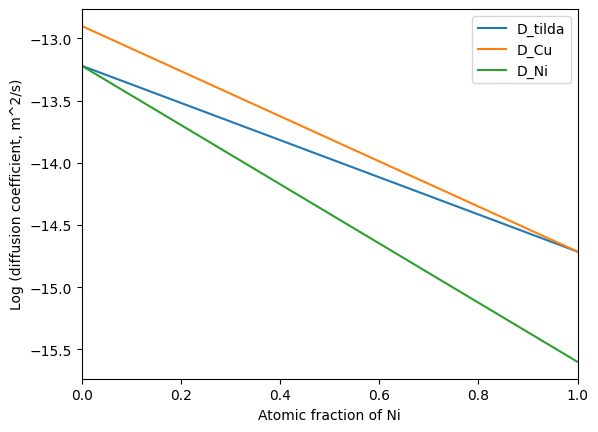

In [17]:
X_A=np.linspace(0,1,100)
values = pd.read_csv('D_tilda.csv', sep=';', header=None, decimal=',') # reads Vegard's digitised graph, but only the end points are used

D_Ni1= values.iloc[0, 1]
D_Ni2= -15.6
D_Cu2= values.iloc[-1, 1]
D_Cu1= -12.9

def D_Cu_lin(X_A):
    return D_Cu1-(D_Cu1-D_Cu2)*X_A

def D_Ni_lin(X_A):
    return D_Ni1-(D_Ni1-D_Ni2)*X_A

#Linear D̃
def D_tilda_lin(X_A):
    return (1-X_A)*D_Ni1+X_A*D_Cu2



plt.plot(X_A, D_tilda_lin(X_A), label='D_tilda')
plt.plot(X_A, D_Cu_lin(X_A), label='D_Cu')
plt.plot(X_A, D_Ni_lin(X_A), label='D_Ni')
plt.xlabel('Atomic fraction of Ni')
plt.ylabel('Log (diffusion coefficient, m^2/s)')
plt.margins(x=0)
plt.legend()
plt.show()

## Part 2 (ii): Diffusion profile across the diffusion couple

With $\tilde{D} = \tilde{D}(C)$ the finite difference scheme from Part 1 has to be modified. Below, the profile is computed with an explicit and an implicit version of the modified scheme.

### Explicit form

With $\tilde{D} = \tilde{D}(C)$ the coefficient has to be evaluated between the nodes, $\tilde{D}_{j+1/2} = \tfrac12(\tilde{D}_j + \tilde{D}_{j+1})$, and updated every time step. The stability limit is set by the largest $\tilde{D}$ over the whole composition range.

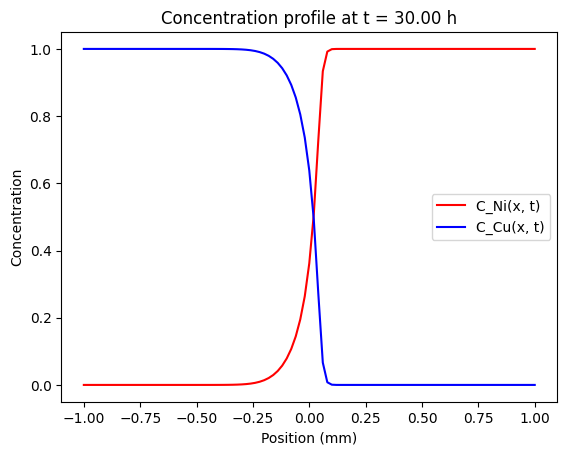

1588.6564694485644


In [18]:
dx_mm = 0.02              # spatial step in mm
dx = dx_mm * 1e-3         # spatial step in m
t_tot=3600*30   # s, 30 hours

N = int(t_tot/ dt)   # number of time steps
M = int(2/dx_mm)       # number of spatial steps

# Grid 
x = np.linspace(-1, 1, M+1) # mm
c = np.zeros(M+1)

# Boundary conditions 
# c(x,0) = 1 for x>0, 0 for x<0  
c[x > 0] = 1
c[x < 0] = 0
c[x == 0] = 0.5 # Condition at midpoint

# Diffusion coefficients, non log
def D_tilda_of_c(c_vec):
    return 10**np.interp(c_vec, X_A, D_tilda_lin(X_A))

# Stability limited timestep
D_max = max(10**D_Ni1, 10**D_Ni2, 10**D_Cu1, 10**D_Cu2)
dt_stability = dx**2 / (2 * D_max)  # stability condition
dt=0.5 * dt_stability  # set dt to half the stability limit for safety
N = int(t_tot/ dt)   # recalculate number of time steps based on new dt

# Time integration loop (explicit finite difference scheme)
def num_sol_nonlinear(c, D_tilda_lin, dx, dt, N, M):
        c_new = c.copy()
        for n in range(N): # time stepping loop
            for m in range(1, M): # spatial loop
                D = D_tilda_lin(c)
                D_half= 0.5 * (D[:-1] + D[1:])
                c_new[m] = c[m] + (dt/dx**2)*(D_half[m]*(c[m+1] - c[m]) - D_half[m-1]*(c[m] - c[m-1]))

            # Apply boundary conditions
            c_new[0] = c[0]  # Dirichlet BC at the left boundary
            c_new[-1] = c[-1]  # Dirichlet BC at the right boundary
            c = c_new.copy()

        return c_new


c_Ni = num_sol_nonlinear(c, D_tilda_of_c, dx, dt, N, M)
c_Cu = 1-c_Ni

# Plot the final concentration profile
plt.plot(x, c_Ni, color='red', label='C_Ni(x, t)')
plt.plot(x, c_Cu, color='blue', label='C_Cu(x, t)')
plt.title('Concentration profile at t = {:.2f} h'.format(t_tot/3600))
plt.xlabel('Position (mm)')
plt.ylabel('Concentration')
plt.legend()
plt.show()

print(dt_stability)

### Implicit form

Here, we need the r as a function of local composition

$$ \frac{\partial C}{\partial t} = \tilde{D} \frac{\partial ^2 C}{\partial x^2} + \frac{\partial C}{\partial x} \frac{\partial \tilde{D}}{\partial x} $$

The first part corresponds to the same as before. The second part can be implemented in two separate schemes multiplied together. 

$$\frac{C_j^{n+1}-C_j^n}{\Delta t} = \tilde D_j^n\,\frac{C_{j+1}^{n+1}-2C_j^{n+1}+C_{j-1}^{n+1}}{(\Delta x)^2} + \left(\frac{\tilde D_{j+1}^n-\tilde D_{j-1}^n}{2\Delta x}\right)\left(\frac{C_{j+1}^{n+1}-C_{j-1}^{n+1}}{2\Delta x}\right)$$

Solved:
$$-\left(\frac{\tilde D_j^n\,\Delta t}{(\Delta x)^2} - \frac{\Delta t\,(\tilde D_{j+1}^n-\tilde D_{j-1}^n)}{4(\Delta x)^2}\right)C_{j-1}^{n+1} + \left(1+\frac{2\tilde D_j^n\,\Delta t}{(\Delta x)^2}\right)C_j^{n+1} - \left(\frac{\tilde D_j^n\,\Delta t}{(\Delta x)^2} + \frac{\Delta t\,(\tilde D_{j+1}^n-\tilde D_{j-1}^n)}{4(\Delta x)^2}\right)C_{j+1}^{n+1} = C_j^n$$

Defining variables to simplify the expression

$$r_j = \frac{\tilde D_j^n\,\Delta t}{(\Delta x)^2}$$

$$s_j = \frac{\Delta t\,(\tilde D_{j+1}^n-\tilde D_{j-1}^n)}{4(\Delta x)^2}$$

In [19]:
# Importing the dataset from the csv file and sorting them


values = pd.read_csv('D_tilda.csv', sep=';', header=None, decimal=',')
composition = values[0].values
lg_D_tilda  = values[1].values


# Interpolating between the values


lg_D_tilda_spline = make_interp_spline(composition, lg_D_tilda, k=3)

In [20]:
# Defining the r for each D

def D_tilda_spline_vector(C1_vector):
    C1_vector = np.clip(C1_vector, composition.min(), composition.max())   # the spline must never extrapolate
    lg_D_tilda_vector = lg_D_tilda_spline(C1_vector)
    return 10**lg_D_tilda_vector * 10**6

def r_vector(D_tilda_vector, dt, dx):
    return D_tilda_vector * dt / dx**2   # vectorised, no loop needed

# Defining the s for each D

def s_vector(D_tilda_vector, dt, dx):
    s = np.zeros(len(D_tilda_vector))
    s[1:-1] = (D_tilda_vector[2:] - D_tilda_vector[:-2]) * dt / (4 * dx**2)
    return s

With the new quantities defined, the same implicit scheme can be used

In [21]:
def main2():
    for step in range(0, t_steps-1):
        D_tilda_vector = D_tilda_spline_vector(C_matrix[step])
        r = r_vector(D_tilda_vector, dt, dx)
        s = s_vector(D_tilda_vector, dt, dx)
        C_matrix[step+1, :] = implicit_system_one_step(C_matrix, r, step, s)

    return C_matrix

In [22]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

def animate_profile(C_matrix, x_min, x_max, dt, title='Concentration bar',
                    total_duration=15, n_frames=100):
    plt.close('all')
    t_steps, x_steps = C_matrix.shape
    x = np.linspace(x_min, x_max, x_steps)

    frames = np.linspace(0, t_steps - 1, min(n_frames, t_steps), dtype=int)
    interval_ms = int(total_duration * 1000 / len(frames))

    fig = plt.figure(figsize=(9, 5))
    ax_bar  = fig.add_axes([0.12, 0.78, 0.80, 0.14])
    ax_line = fig.add_axes([0.12, 0.14, 0.80, 0.52])

    img = ax_bar.imshow(C_matrix[[0]], cmap='gray', aspect='auto',
                        vmin=0, vmax=1, extent=[x_min, x_max, 0, 1])
    ax_bar.set_yticks([])
    ax_bar.set_xticks([])
    ttl = ax_bar.set_title(f'{title}, t = 0.00 hours')

    line, = ax_line.plot(x, C_matrix[0], lw=2)
    ax_line.set_xlim(x_min, x_max)
    ax_line.set_ylim(-0.02, 1.02)
    ax_line.set_xlabel('$x$ [mm]')
    ax_line.set_ylabel('$C$')
    ax_line.grid(alpha=0.3, lw=0.5)

    def update(i):
        n = frames[i]
        img.set_data(C_matrix[[n]])
        line.set_ydata(C_matrix[n])
        ttl.set_text(f'{title}, t = {n*dt/3600:.2f} hours')
        return img, line, ttl

    anim = FuncAnimation(fig, update, frames=len(frames),
                         interval=interval_ms, blit=False)
    plt.close(fig)                 # prevents the last frame from also being shown as a static image
    display(HTML(anim.to_jshtml()))

In [23]:
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main2()
animate_profile(C_matrix, x_min, x_max, dt,
                title='Interdiffusion, concentration-dependent D');

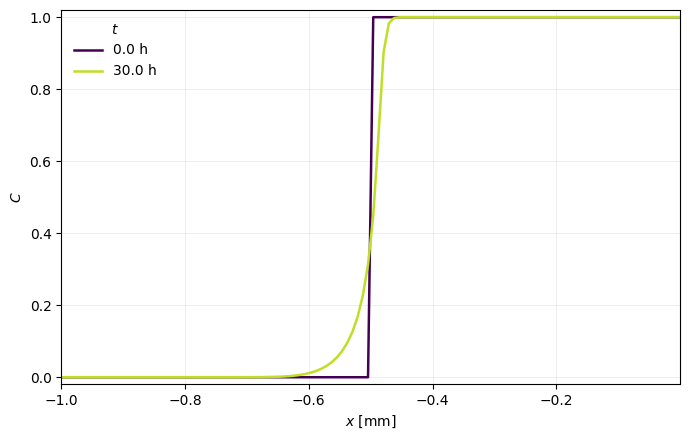

In [24]:
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main2()
plot_profiles(C_matrix, x_min, x_max, dt, n_curves=2)

In [25]:
print("C range:", C_matrix.min(), C_matrix.max())
print("mass start:", C_matrix[0].sum(), " end:", C_matrix[-1].sum())

C range: 0.0 1.0
mass start: 60.0  end: 60.2155707038852


### Explicit flux form, 0–300 h

Same explicit flux form as in Part 1 (iii): `central_diff` computes the flux $J_{j+1/2}$ on the faces between the nodes,
and $C^{n+1} = C^n + \Delta t\,\partial C/\partial t$. The only change is that $D$ is now a list,
$\tilde{D}_j = \tilde{D}(X_{Ni,j})$ from Part 2 (i), which is updated every time step. The time step is set from
the largest $\tilde{D}$ over the whole composition range, so the stability criterion holds throughout.

Initial condition from the assignment: pure Ni for $x < 0$ and pure Cu for $x > 0$. The ends have zero flux.

Number of time steps: 6480  dt = 166.7 s


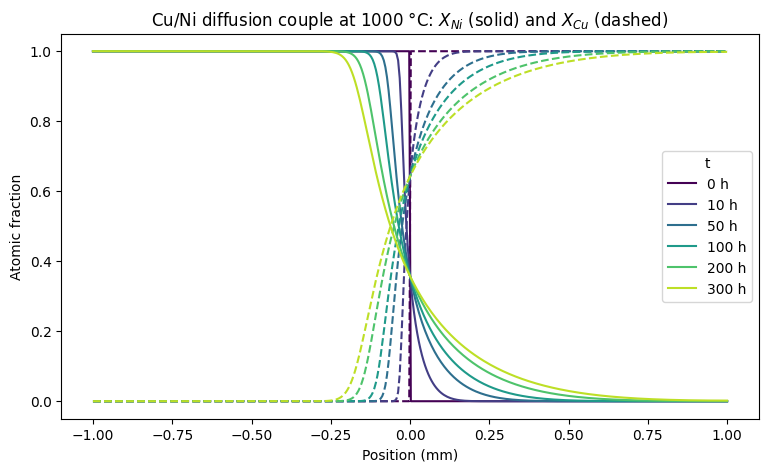

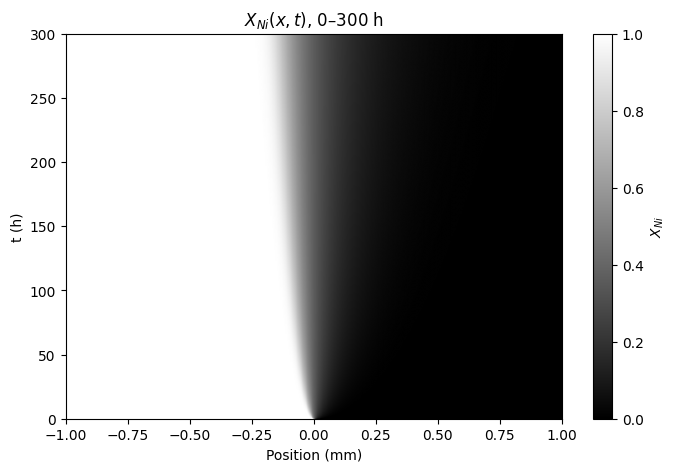

In [26]:
# Part 2 (ii): interdiffusion, reusing central_diff from Part 1 (iii)
# C = X_Ni (atomic fraction Ni), X_Cu = 1 - X_Ni

def D_tilde_SI(X_Ni):
    # D_tilda_lin from Part 2 (i) gives log10(D) in m^2/s, with X_A = X_Ni
    return 10**D_tilda_lin(X_Ni)

def iteration_interdiff(C, dx, t_end, alpha=0.4):
    # dt from stability with the largest D-tilde over the whole composition range
    D_max = D_tilde_SI(np.array([0.0, 1.0])).max()
    dt = alpha * dx**2 / D_max
    t = 0
    C = np.array(C, dtype=float)
    history = [C.copy()]
    times = [0.0]
    while t < t_end:
        D_list = D_tilde_SI(C)                           # D-tilde in each node
        dcdt, J = central_diff(C, None, dx, D_list=D_list)
        C = C + dt * dcdt
        C[0] = C[1]; C[-1] = C[-2]                       # zero-flux ends
        t += dt
        history.append(C.copy())
        times.append(t)
    return np.array(history), np.array(times)

#----------- Parameters -----------------
grid_points = 400
t_end = 3600 * 300     # s, 300 hours
L = 1e-3               # m

positions = np.linspace(-L, L, grid_points)
dx = 2*L / (grid_points - 1)

X_Ni_start = np.zeros(grid_points)
X_Ni_start[:grid_points//2] = 1.0     # Ni for x < 0, Cu for x > 0

X_Ni_hist, times = iteration_interdiff(X_Ni_start, dx, t_end)
print("Number of time steps:", len(times) - 1, " dt =", round(times[1], 1), "s")

# ------------- Profiles at different times -------------
show_hours = [0, 10, 50, 100, 200, 300]
line_colors = plt.cm.viridis(np.linspace(0, 0.9, len(show_hours)))

plt.figure(figsize=(9, 5))
for col, h in zip(line_colors, show_hours):
    n = np.argmin(abs(times - h*3600))
    plt.plot(positions*1e3, X_Ni_hist[n], color=col, label=f'{h} h')
    plt.plot(positions*1e3, 1 - X_Ni_hist[n], color=col, ls='--')
plt.xlabel('Position (mm)')
plt.ylabel('Atomic fraction')
plt.title('Cu/Ni diffusion couple at 1000 °C: $X_{Ni}$ (solid) and $X_{Cu}$ (dashed)')
plt.legend(title='t')
plt.show()

# ------------- X_Ni(x, t) as a colour map -------------
plt.figure(figsize=(8, 5))
plt.imshow(X_Ni_hist, aspect='auto', origin='lower', cmap='gray',
           extent=[-L*1e3, L*1e3, 0, times[-1]/3600])
plt.colorbar(label='$X_{Ni}$')
plt.xlabel('Position (mm)')
plt.ylabel('t (h)')
plt.title('$X_{Ni}(x, t)$, 0–300 h')
plt.show()

## Part 2 (iii): Fluxes of Cu and Ni, and the Kirkendall velocity

`central_diff` is used again, now with the intrinsic diffusion coefficients from Part 2 (i), on the profiles computed in Part 2 (ii):

- $J_{Cu} = -D_{Cu}\,\partial C_{Cu}/\partial x$ and $J_{Ni} = -D_{Ni}\,\partial C_{Ni}/\partial x$, measured relative to the lattice planes.
- Since Cu and Ni do not jump equally fast, there is a net atom flux towards the Ni side. The lattice planes (and markers) move the opposite way with
  $v = -(J_{Cu} + J_{Ni})/C_0 = (D_{Cu} - D_{Ni})\,\partial X_{Cu}/\partial x$.

$C_0 = 1/V_m$ with $V_m \approx 7.1$ cm³/mol (Cu, assumed equal for Ni), which converts the fluxes to mol m$^{-2}$ s$^{-1}$.

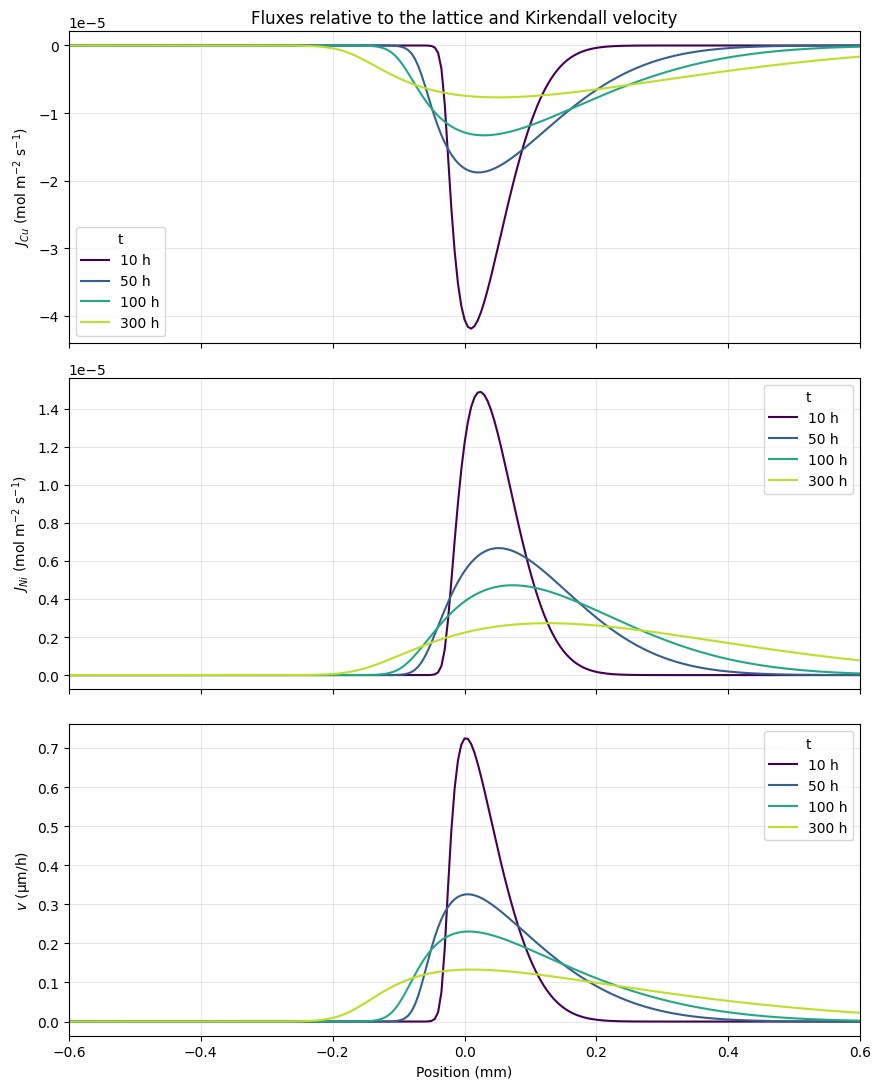

In [27]:
# Part 2 (iii): fluxes relative to the lattice and the Kirkendall velocity

def D_Cu_SI(X_Ni):
    return 10**D_Cu_lin(X_Ni)   # m^2/s

def D_Ni_SI(X_Ni):
    return 10**D_Ni_lin(X_Ni)   # m^2/s

V_m = 7.1e-6     # m^3/mol
C0 = 1 / V_m     # mol/m^3

def fluxes(X_Ni, dx):
    X_Cu = 1 - X_Ni
    _, J_Cu = central_diff(X_Cu, None, dx, D_list=D_Cu_SI(X_Ni))   # relative to the lattice
    _, J_Ni = central_diff(X_Ni, None, dx, D_list=D_Ni_SI(X_Ni))
    v = -(J_Cu + J_Ni)                                             # = (D_Cu - D_Ni) dX_Cu/dx
    return C0 * J_Cu, C0 * J_Ni, v

x_face = 0.5 * (positions[1:] + positions[:-1])   # J lives on the faces between the nodes

show_hours = [10, 50, 100, 300]
line_colors = plt.cm.viridis(np.linspace(0, 0.9, len(show_hours)))

fig, ax = plt.subplots(3, 1, figsize=(9, 11), sharex=True)
for col, h in zip(line_colors, show_hours):
    n = np.argmin(abs(times - h*3600))
    J_Cu, J_Ni, v = fluxes(X_Ni_hist[n], dx)
    ax[0].plot(x_face*1e3, J_Cu, color=col, label=f'{h} h')
    ax[1].plot(x_face*1e3, J_Ni, color=col, label=f'{h} h')
    ax[2].plot(x_face*1e3, v*1e6*3600, color=col, label=f'{h} h')   # m/s -> um/h
ax[0].set_ylabel('$J_{Cu}$ (mol m$^{-2}$ s$^{-1}$)')
ax[1].set_ylabel('$J_{Ni}$ (mol m$^{-2}$ s$^{-1}$)')
ax[2].set_ylabel('$v$ (µm/h)')
ax[2].set_xlabel('Position (mm)')
ax[0].set_title('Fluxes relative to the lattice and Kirkendall velocity')
for a in ax:
    a.set_xlim(-0.6, 0.6)
    a.grid(alpha=0.3)
    a.legend(title='t')
plt.tight_layout()
plt.show()

## Part 2 (iv): Total amount of Cu transported across the initial mid-plane

There was no Cu for $x < 0$ at the start, so everything found there after 300 h has crossed the mid-plane:
$\int_{-L}^{0} C_{Cu}(x, 300\,\mathrm{h})\,dx$. This is checked against the time integral of the interdiffusion flux through $x = 0$,
which must give the same answer.

In [28]:
# Part 2 (iv): amount of Cu across the initial mid-plane after 300 h
mid = grid_points//2 - 1          # the face between node mid and mid+1 lies at x = 0

# 1) From the profile: all Cu found on the left side
X_Cu_end = 1 - X_Ni_hist[-1]
M_profile = np.sum(X_Cu_end[:grid_points//2]) * dx          # m

# 2) From the flux through x = 0, integrated over time
J_mid = []
for C in X_Ni_hist:
    _, J = central_diff(1 - C, None, dx, D_list=D_tilde_SI(C))   # Cu flux in the lab frame
    J_mid.append(J[mid])
M_flux = -np.sum(np.array(J_mid[:-1]) * np.diff(times))         # m, same time steps as in the loop (negative J = towards the left)

print(f"Cu across the mid-plane after {times[-1]/3600:.0f} h:")
print(f"  from the profile: {M_profile*1e6:.2f} µm of pure Cu = {M_profile*C0:.2f} mol/m^2")
print(f"  from the flux:    {M_flux*1e6:.2f} µm of pure Cu = {M_flux*C0:.2f} mol/m^2")
print("The same amount of Ni has moved the opposite way (lab frame).")

Cu across the mid-plane after 300 h:
  from the profile: 71.07 µm of pure Cu = 10.01 mol/m^2
  from the flux:    71.07 µm of pure Cu = 10.01 mol/m^2
The same amount of Ni has moved the opposite way (lab frame).


# Extra: Monte Carlo simulation of vacancy diffusion

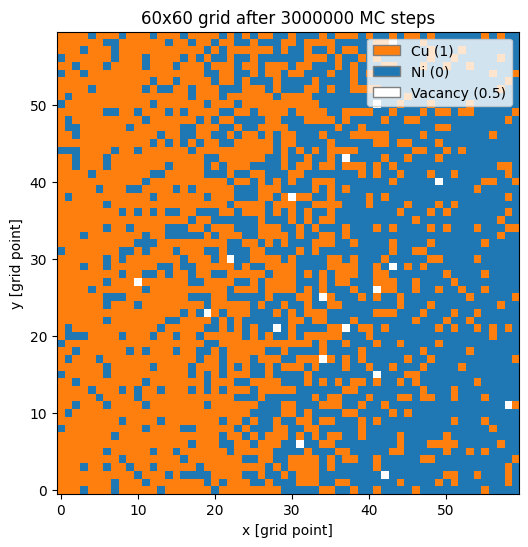

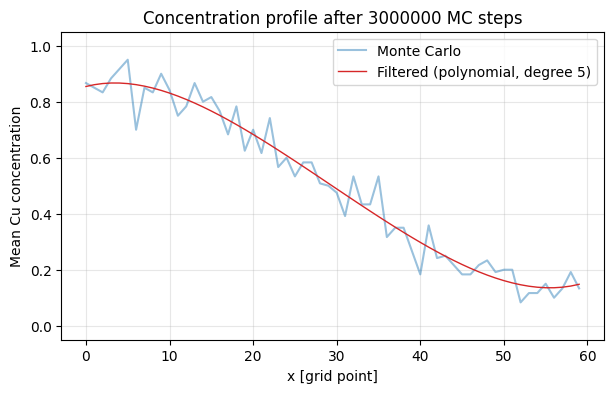

In [29]:
# Monte Carlo approach to find Fick's first law through vacancies

#----------- Parameters -----------------
x_grid = 60
y_grid = 60
MC_steps = 1e6*3
vacancy_volume = 0.5 # percent

MC_steps = int(MC_steps)
vacancy_volume = vacancy_volume/100

Grid = np.zeros((x_grid, y_grid))
Grid[:len(Grid)//2,:] = 1
n_vacancies = int(vacancy_volume * x_grid * y_grid)
for i in range(n_vacancies):
    x = np.random.randint(0, x_grid)
    y = np.random.randint(0, y_grid)
    Grid[x, y] = 0.5

# ------------------ Monte Carlo part -----------------------------
def Monte_carlo_diff(Grid, MC):
    vacancies = np.argwhere(Grid == 0.5)   # array with [x, y] for each vacancy
    # pre-generate some values for faster code
    choice = np.random.randint(0, len(vacancies), MC)
    dxs = np.random.choice([-1, 1], MC)
    dys = np.random.choice([-1, 1], MC)
    for i in range(MC):
        inx = choice[i]
        x, y = vacancies[inx]
        dx = dxs[i]
        dy = dys[i]
        if x + dx < 0 or x + dx >= x_grid:
            dx = 0
        if y + dy < 0 or y + dy >= y_grid:
            dy = 0
        neighbour = Grid[x + dx, y + dy]
        if neighbour != 0.5:                 # the neighbour is an atom (Cu or Ni), not another vacancy
            Grid[x, y] = neighbour           # the atom moves into where the vacancy was
            Grid[x + dx, y + dy] = 0.5       # the vacancy ends up where the atom was
            vacancies[inx] = [x + dx, y + dy]  # update the position of the vacancy
    return Grid

Grid = Monte_carlo_diff(Grid, MC_steps)

# ---------------------- Plotting ----------------------
colors = ListedColormap(['tab:blue', 'white', 'tab:orange'])
norm = BoundaryNorm([-0.25, 0.25, 0.75, 1.25], colors.N)
plt.figure(figsize=(6, 6))
plt.imshow(Grid.T, cmap=colors, norm=norm, origin='lower', interpolation='nearest')
plt.xlabel('x [grid point]')
plt.ylabel('y [grid point]')
plt.title(f'{x_grid}x{y_grid} grid after {MC_steps} MC steps')
plt.legend(handles=[Patch(facecolor='tab:orange', edgecolor='grey', label='Cu (1)'),Patch(facecolor='tab:blue', edgecolor='grey', label='Ni (0)'),Patch(facecolor='white', edgecolor='grey', label='Vacancy (0.5)')],loc='upper right')
plt.show()

#------------- Mean concentration per x position --------
# the mean over all y for each x, i.e. np.mean(Grid[i,:]) for i = 0..x_grid-1
mean_profile = Grid.mean(axis=1)

# Filtering: least-squares fit of one polynomial over the whole profile.
degree = 5
mean_smoothed = np.polyval(np.polyfit(np.arange(x_grid), mean_profile, degree), np.arange(x_grid))

plt.figure(figsize=(7, 4))
plt.plot(np.arange(x_grid), mean_profile, '-', ms=3, alpha=0.45, label='Monte Carlo')
plt.plot(np.arange(x_grid), mean_smoothed, '-', lw=1, color='tab:red', label=f'Filtered (polynomial, degree {degree})')
plt.xlabel('x [grid point]')
plt.ylabel('Mean Cu concentration')
plt.title(f'Concentration profile after {MC_steps} MC steps')
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()